In [ ]:
##

In [46]:
pip install PyWavelets

  Using cached pywavelets-1.9.0-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
Using cached pywavelets-1.9.0-cp313-cp313-win_amd64.whl (4.2 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\aryck\Desktop\NMR\nmr_env\Scripts\python.exe -m pip install --upgrade pip


In [1]:
# Manipulação, plots
import numpy as np
import pandas as pd
# import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.decomposition import PCA

# pré-processamento
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
from scipy.special import erfcx
import pywt

# Rede neural
import torch
import torch.nn as nn

In [2]:
## definindo seed
seed = 765
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [ ]:
## Carregando os dados

In [3]:
rmn_df = pd.read_csv('RMN_data/GulfCoast_RMN_Synthetic.csv')
rmn_df

,Echo_1,Echo_2,Echo_3,Echo_4,Echo_5,Echo_6,Echo_7,Echo_8,Echo_9,Echo_10,...,Echo_2995,Echo_2996,Echo_2997,Echo_2998,Echo_2999,Echo_3000,Swirr_PHIX,MBVI,MPHI,PHIX
0,6.460234,6.001470,5.479225,6.220040,5.654541,6.069789,6.067709,5.816069,5.010683,5.779317,...,-0.217362,-0.210865,-0.185724,0.324967,-0.295100,-0.191369,0.656594,0.244925,0.309553,0.373023
1,6.665392,6.266545,6.503391,5.270580,5.753246,6.071110,5.988263,5.752052,5.681029,6.169680,...,-0.153615,0.192474,0.014489,0.145954,-0.170708,0.246763,0.705920,0.251558,0.324391,0.356355
2,6.664616,6.647278,6.625650,6.035979,5.933394,6.005520,6.078027,6.403704,6.530694,5.805684,...,-0.303743,-0.142687,-0.028363,-0.095744,-0.291898,0.176739,0.743156,0.258190,0.339230,0.347424
3,6.685771,7.162382,5.472680,6.431469,5.995483,6.915485,5.571884,6.260882,6.230861,5.922057,...,-0.225752,-0.694672,-0.134843,0.103676,0.063376,0.045555,0.677602,0.236270,0.327660,0.348686
4,5.770483,6.076646,6.212651,5.957674,5.775050,5.648643,5.761101,5.592177,5.407010,4.881706,...,0.263412,-0.080678,0.093621,0.147829,0.605603,0.127397,0.621254,0.221170,0.313470,0.356006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570,4.966289,4.846922,5.338174,5.108003,5.200211,4.335958,4.792379,5.037254,5.028233,5.226749,...,0.016798,0.527388,-0.272707,0.858933,-0.038283,0.198241,0.455738,0.166560,0.265820,0.365474
571,5.787658,5.921521,6.228244,6.519006,6.445536,5.950092,5.889329,5.756856,5.802752,5.509340,...,0.138340,-0.186543,-0.119607,0.364478,-0.400137,-0.000522,0.603281,0.204060,0.318200,0.338250
572,8.472379,8.200503,7.734694,7.478999,7.139354,7.408908,7.665833,7.053142,7.249036,7.621642,...,0.222808,0.158697,0.176964,0.317897,-0.220562,0.269329,0.761814,0.255830,0.406020,0.335817
573,8.090107,8.547713,8.536526,8.672580,7.878514,7.538156,8.573747,7.721918,8.286157,7.805499,...,0.321430,-0.153829,0.128334,0.602452,0.112477,0.159523,0.823391,0.276590,0.439990,0.335916


In [12]:
# Set plotting style
sns.set_theme(style="whitegrid")

# Load data (assuming you just ran this)
df = pd.read_csv('RMN_data/GulfCoast_RMN_Synthetic.csv')

# Separate features (Echoes) and Target (Swirr_PHIX)
X = df.drop(columns=['Swirr_PHIX',"MBVI",	"MPHI",	"PHIX"])
y = df['Swirr_PHIX']

# Basic sanity check
print(f"Dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Number of echo features: {X.shape[1]}")

# Look at the statistical summary of the target
display(pd.DataFrame(y.describe()).T)

Dataset shape: (575, 3004)
Missing values: 0
Number of echo features: 3000


,count,mean,std,min,25%,50%,75%,max
Swirr_PHIX,575.0,0.434547,0.194175,0.115263,0.275361,0.410195,0.56026,0.967319


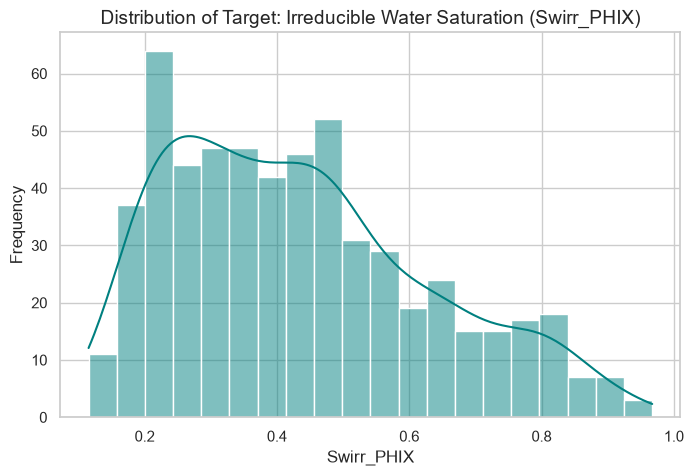

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(y, bins=20, kde=True, color='teal')
plt.title('Distribution of Target: Irreducible Water Saturation (Swirr_PHIX)', fontsize=14)
plt.xlabel('Swirr_PHIX')
plt.ylabel('Frequency')
plt.show()

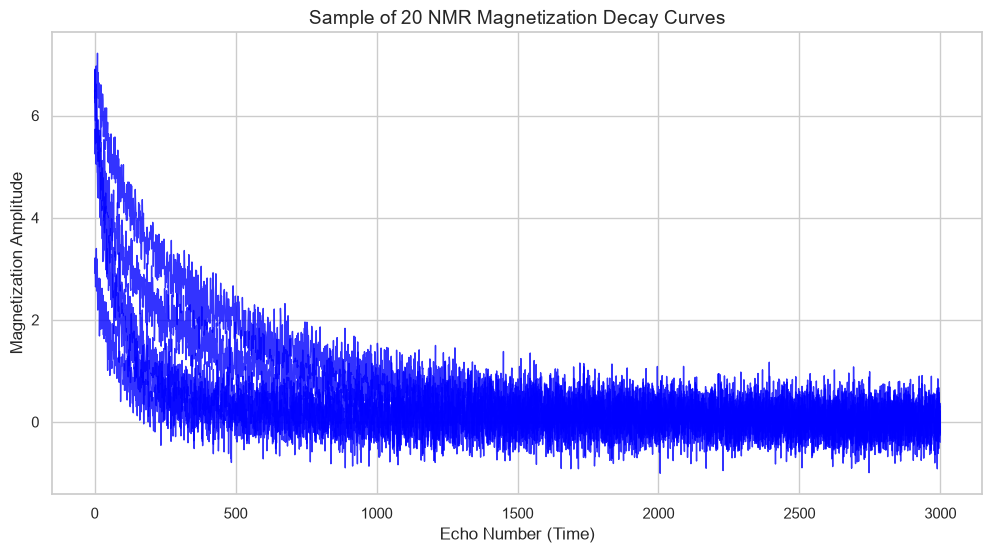

In [7]:
plt.figure(figsize=(12, 6))

# Plot a random sample of 20 curves to avoid overcrowding
sample_indices = np.random.choice(X.index, size=5, replace=False)

for idx in sample_indices:
    plt.plot(X.loc[idx].values, color='blue', alpha=0.8, linewidth=1)

plt.title('Sample of 20 NMR Magnetization Decay Curves', fontsize=14)
plt.xlabel('Echo Number (Time)')
plt.ylabel('Magnetization Amplitude')
plt.show()

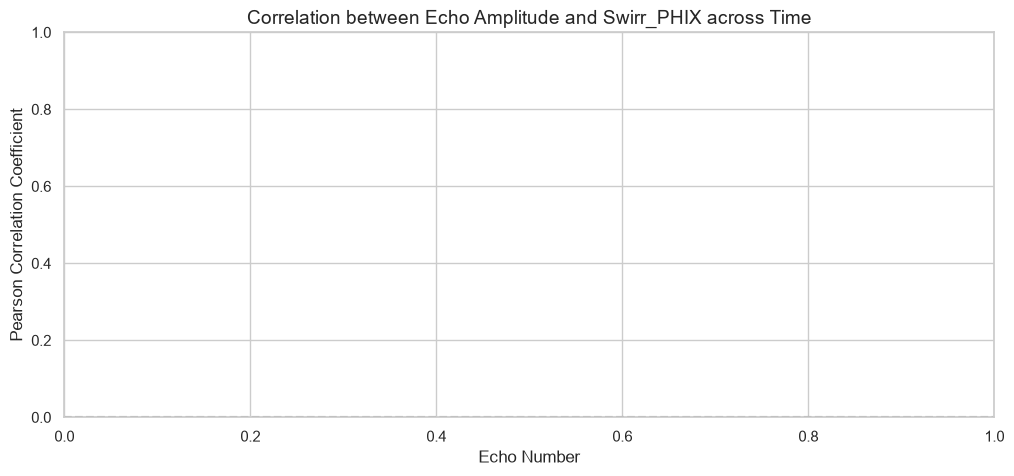

In [13]:
# Calculate correlation of each echo with the target
correlations = X.apply(lambda col: col.corr(y))

plt.figure(figsize=(12, 5))
# plt.plot(echo_numbers, correlations.values, color='purple', linewidth=2)
plt.title('Correlation between Echo Amplitude and Swirr_PHIX across Time', fontsize=14)
plt.xlabel('Echo Number')
plt.ylabel('Pearson Correlation Coefficient')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
## Suavização

In [19]:
def DWTdenoise(noisy, wvlet='db6', level=6, mode='soft'):
    # decomposição
    coeffs = pywt.wavedec(noisy, wvlet, level=level)#, mode='smooth')
    cA, cD = coeffs[0], coeffs[1:]

    # Nível de ruído (estimativa)
    sigma = np.median(np.abs(cD[-1])) / 0.6745 *2
    T = sigma * np.sqrt(2 * np.log(len(noisy)))

    # Thresholding e retorna sinal reconstruído
    coeffs_thresh = [cA] + [pywt.threshold(cd, T, mode=mode) for cd in cD]
    return pywt.waverec(coeffs_thresh, wvlet), coeffs_thresh

In [20]:
def DWTdenoise(noisy, wvlet='db6', level=6, mode='soft'):
    # CORREÇÃO: Garante que o array seja um NumPy array "writable" copiando os dados
    noisy_array = np.array(noisy, copy=True)
    
    # Decomposição
    coeffs = pywt.wavedec(noisy_array, wvlet, level=level)
    cA, cD = coeffs[0], coeffs[1:]

    # Nível de ruído (estimativa)
    sigma = np.median(np.abs(cD[-1])) / 0.6745 * 2
    T = sigma * np.sqrt(2 * np.log(len(noisy_array)))

    # Thresholding
    coeffs_thresh = [cA] + [pywt.threshold(cd, T, mode=mode) for cd in cD]
    
    # Reconstrução
    reconstructed = pywt.waverec(coeffs_thresh, wvlet)
    
    # Retorna o sinal reconstruído e os coeficientes
    return reconstructed[:len(noisy_array)], coeffs_thresh

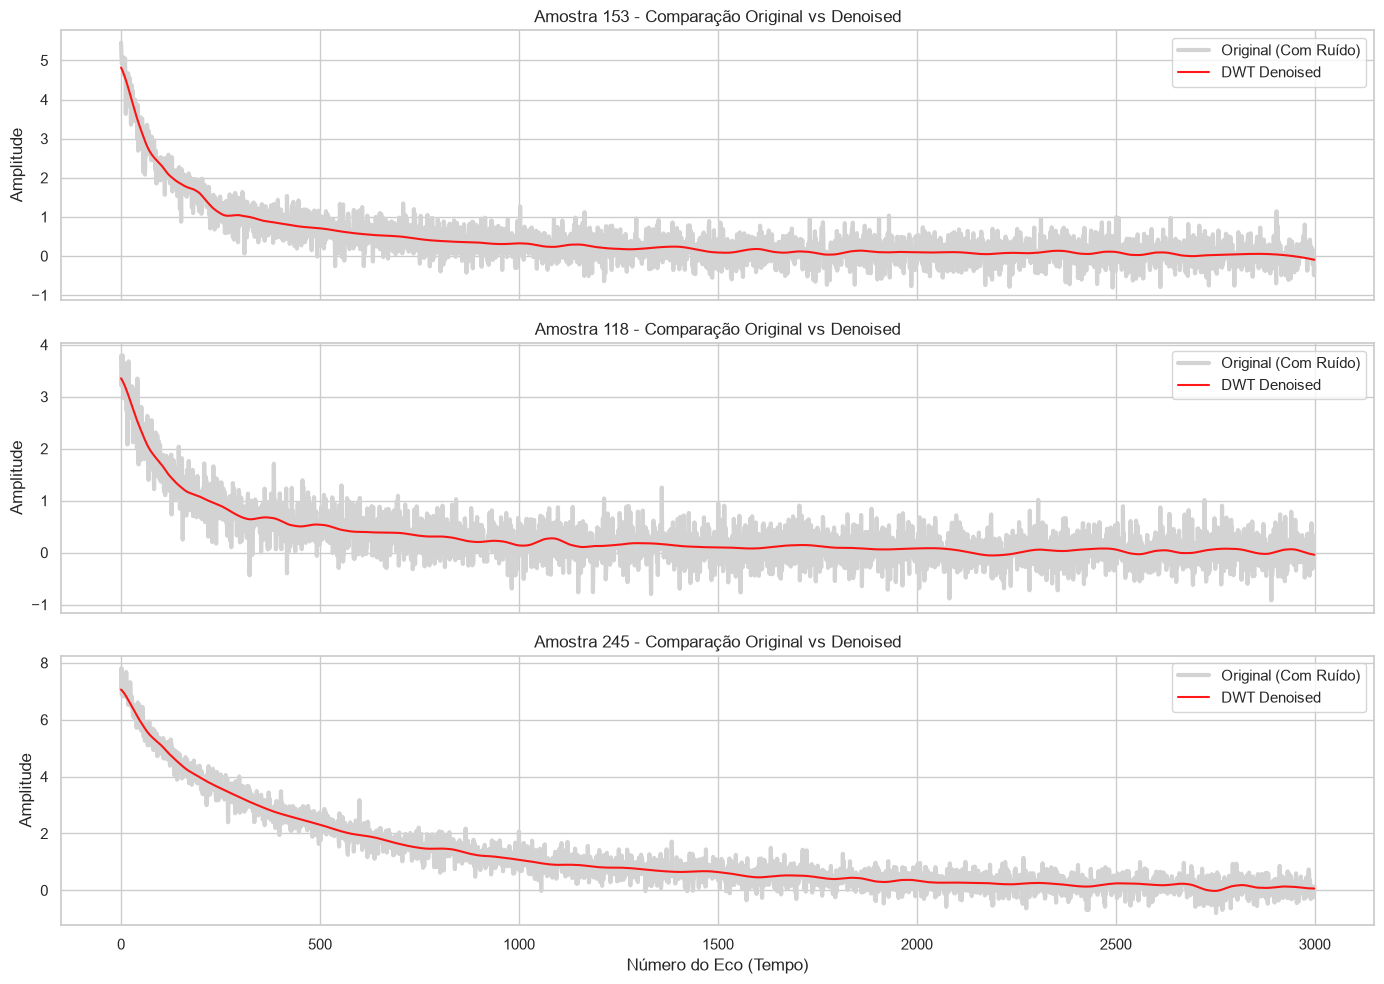

In [21]:
# Seleciona 3 amostras aleatórias para plotar
np.random.seed(42) # Semente fixa para reprodutibilidade
sample_indices = np.random.choice(X.index, size=3, replace=False)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, idx in enumerate(sample_indices):
    original_signal = X.loc[idx].values
    
    # Aplica o filtro (pegamos apenas o índice [0], que é o sinal reconstruído)
    denoised_signal, _ = DWTdenoise(original_signal)
    
    # Plota o original (espesso e claro ao fundo) e o filtrado (fino e escuro à frente)
    axes[i].plot(original_signal, color='lightgray', linewidth=3, label='Original (Com Ruído)')
    axes[i].plot(denoised_signal, color='red', linewidth=1.5, alpha=0.9, label='DWT Denoised')
    
    axes[i].set_title(f'Amostra {idx} - Comparação Original vs Denoised', fontsize=12)
    axes[i].set_ylabel('Amplitude')
    axes[i].legend()

axes[-1].set_xlabel('Número do Eco (Tempo)', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
import time

print("Aplicando filtro DWT em todo o dataset...")
start_time = time.time()

# Aplica a função linha por linha e extrai apenas o sinal filtrado [0]
X_denoised_array = np.array([DWTdenoise(row)[0] for row in X.values])

# Converte de volta para um DataFrame do Pandas para manter as colunas e índices
X_denoised = pd.DataFrame(X_denoised_array, columns=X.columns, index=X.index)

print(f"Filtragem concluída em {time.time() - start_time:.2f} segundos!")
print(f"Shape do novo dataset: {X_denoised.shape}")

Aplicando filtro DWT em todo o dataset...
Filtragem concluída em 0.47 segundos!
Shape do novo dataset: (575, 3000)


In [23]:
X_denoised

,Echo_1,Echo_2,Echo_3,Echo_4,Echo_5,Echo_6,Echo_7,Echo_8,Echo_9,Echo_10,...,Echo_2991,Echo_2992,Echo_2993,Echo_2994,Echo_2995,Echo_2996,Echo_2997,Echo_2998,Echo_2999,Echo_3000
0,5.646703,5.618930,5.589814,5.559431,5.527793,5.494974,5.460883,5.425352,5.388406,5.350029,...,-0.030232,-0.032303,-0.034369,-0.036417,-0.038454,-0.040493,-0.042534,-0.044587,-0.046641,-0.048678
1,5.850586,5.824165,5.796358,5.767254,5.736870,5.705293,5.672422,5.638069,5.602266,5.565000,...,0.039408,0.040014,0.040609,0.041216,0.041824,0.042430,0.043026,0.043598,0.044171,0.044785
2,6.102272,6.074815,6.045956,6.015786,5.984320,5.951647,5.917665,5.882186,5.845241,5.806817,...,-0.001892,-0.003205,-0.004511,-0.005821,-0.007127,-0.008427,-0.009716,-0.010988,-0.012251,-0.013519
3,6.011791,5.984184,5.955282,5.925151,5.893803,5.861304,5.827569,5.792442,5.755944,5.718060,...,0.022246,0.020859,0.019512,0.018191,0.016904,0.015649,0.014432,0.013262,0.012123,0.010993
4,5.556719,5.533292,5.508777,5.483227,5.456650,5.429098,5.400501,5.370733,5.339810,5.307716,...,0.189104,0.190962,0.192780,0.194568,0.196319,0.198027,0.199690,0.201300,0.202864,0.204398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570,4.822897,4.804627,4.785428,4.765362,4.744438,4.722716,4.700128,4.676549,4.652000,4.626473,...,0.108448,0.111275,0.114084,0.116888,0.119680,0.122454,0.125208,0.127930,0.130634,0.133345
571,5.852786,5.828668,5.803327,5.776841,5.749225,5.720553,5.690738,5.659618,5.627218,5.593529,...,-0.003474,-0.003594,-0.003714,-0.003833,-0.003951,-0.004072,-0.004196,-0.004324,-0.004456,-0.004589
572,7.375384,7.346854,7.316942,7.285720,7.253197,7.219447,7.184376,7.147818,7.109793,7.070286,...,0.097711,0.097776,0.097839,0.097895,0.097945,0.097989,0.098027,0.098061,0.098086,0.098096
573,7.983331,7.953821,7.922800,7.890364,7.856531,7.821395,7.784847,7.746685,7.706942,7.665604,...,0.148977,0.151177,0.153331,0.155445,0.157520,0.159563,0.161572,0.163541,0.165484,0.167418


In [17]:
print("Normalizando cada sinal individualmente (Min-Max por linha)...")

# Encontra o mínimo e máximo para cada linha
X_min = X_denoised.min(axis=1)
X_max = X_denoised.max(axis=1)

# Aplica a normalização linha por linha
X_norm = X_denoised.subtract(X_min, axis=0).divide(X_max - X_min, axis=0)

Normalizando cada sinal individualmente (Min-Max por linha)...


In [18]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

print("Removendo os últimos 1000 ecos...")

# Fatiamento (slicing) do DataFrame: pega todas as linhas, e colunas até a antepenúltima 1000ª
X_norm_trunc = X_norm.iloc[:, :-1000]

print(f"Shape anterior: {X_norm.shape}")
print(f"Novo shape: {X_norm_trunc.shape}")

# Re-plotando para confirmar o fatiamento
plt.figure(figsize=(8, 6))

cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=y.min(), vmax=y.max())

for idx in X_500.index:
    target_value = y.loc[idx]
    color = cmap(norm(target_value))
    plt.plot(X_500.loc[idx].values, color=color, alpha=0.3, linewidth=1)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Saturação de Água Irredutível ($Sw_{irr}$)', fontsize=12, labelpad=15)

plt.title('Decaimentos de RMN Normalizados (Truncados em 2000 ecos)', fontsize=14, pad=15)
plt.xlabel('Número do Eco (Tempo)', fontsize=12)
plt.ylabel('Amplitude Normalizada', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Removendo os últimos 1000 ecos...
Shape anterior: (575, 3000)
Novo shape: (575, 2000)


NameError: name 'X_500' is not defined

<Figure size 800x600 with 0 Axes>

In [107]:
# Cria um array que repete o mesmo número 4 vezes (ex: 0,0,0,0, 1,1,1,1, ..., 499,499,499,499)
agrupamentos = np.arange(X_norm_trunc.shape[1]) // 4

# CORREÇÃO: Transpõe (.T), agrupa, calcula a média e transpõe de volta (.T)
X_500 = X_norm_trunc.T.groupby(agrupamentos).mean().T

# Renomeia as colunas para manter a organização
X_500.columns = [f'Echo_Bin_{i+1}' for i in range(500)]

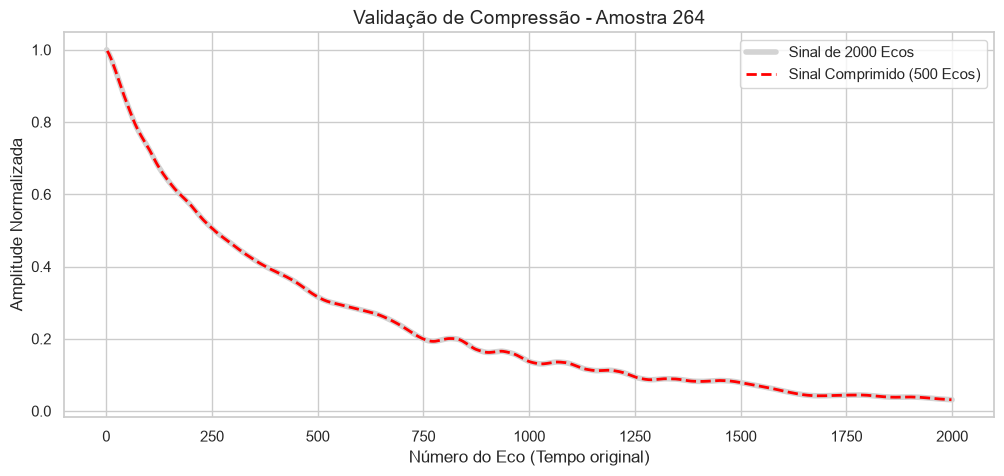

In [108]:
plt.figure(figsize=(12, 5))

# Escolhe uma amostra aleatória
idx = np.random.choice(X_500.index)

# Eixo X original (1 a 2000) e o novo eixo X (espaçado de 4 em 4 para alinhar visualmente)
x_original = np.arange(1, 2001)
x_comprimido = np.arange(2.5, 2001, 4) # Centralizado no meio dos 4 ecos

plt.plot(x_original, X_norm_trunc.loc[idx].values, color='lightgray', linewidth=4, label='Sinal de 2000 Ecos')
plt.plot(x_comprimido, X_500.loc[idx].values, color='red', linestyle='--', linewidth=2, label='Sinal Comprimido (500 Ecos)')

plt.title(f'Validação de Compressão - Amostra {idx}', fontsize=14)
plt.xlabel('Número do Eco (Tempo original)', fontsize=12)
plt.ylabel('Amplitude Normalizada', fontsize=12)
plt.legend()
plt.show()

In [110]:
# Concatena as features truncadas e a coluna alvo ao longo do eixo das colunas (axis=1)
y = df[['Swirr_PHIX',"MBVI",	"MPHI",	"PHIX"]]

model_input_df = pd.concat([X_500, y], axis=1)

# Verifica o shape final (deve ter 575 linhas e 2001 colunas)
print(f"Shape do dataset final: {model_input_df.shape}")

# Salva em um único arquivo CSV
model_input_df.to_csv('model_input.csv', index=False)

Shape do dataset final: (575, 504)
